In [ ]:
import numpy as np
import pandas as pd

# 只保留sample_6相关的文件
files_sample_6 = [
    "rebuttel/WV3_Reduced/LGPNet/results/model_epoch_370/sample_0.npz",
    "rebuttel/WV3_Reduced/BWNET_LGPNet/results/model_epoch_370/sample_0.npz"
]

# 初始化数据存储
eigenvalues_sample_6 = {file: [] for file in files_sample_6}

# 读取数据并计算特征值
for file in files_sample_6:
    data = np.load(file)
    cov = data['cov'].squeeze()
    # 计算特征值
    eigenvalues_sample_6[file] = np.linalg.eigvals(cov).mean(axis=0)

# 将结果保存为CSV
eigenvalues_combined_sorted = {file: eigenvalues_sample_6[file] for file in eigenvalues_sample_6}

# 创建DataFrame
df = pd.DataFrame(eigenvalues_combined_sorted)
csv_file = "eigenvalues_sample_0.csv"
df.to_csv(csv_file, index=False)

csv_file  # 返回保存的CSV路径


'eigenvalues_sample_0.csv'

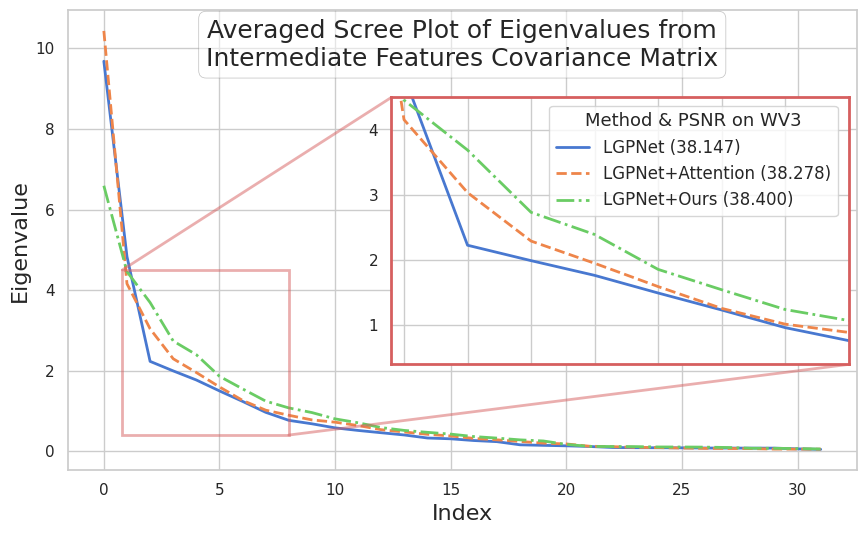

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

fm.fontManager.addfont('/home/kndy666/miniconda3/envs/ML/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/times.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

# 读取CSV文件
df = pd.read_csv("eigenvalues_sample_6.csv")

# 对每一列进行降序排序
df_sorted = df.apply(lambda x: x.sort_values(ascending=False).values)

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# Line styles for differentiation
line_styles = ['-', '--', '-.', ':']

# Initialize the plot
fig, ax = plt.subplots(figsize=(9, 5.5))

# Plot each column using Seaborn's lineplot with different line styles
for i, column in enumerate(df_sorted.columns):
    sns.lineplot(data=df_sorted, x=df_sorted.index, y=df_sorted[column], 
                 label=column, markers='o', markersize=6, linewidth=2, 
                 linestyle=line_styles[i % len(line_styles)], ax=ax)

# Title and labels
plt.xlabel('Index', fontsize=16)
plt.ylabel('Eigenvalue', fontsize=16)
title = plt.title('Averaged Scree Plot of Eigenvalues from\nIntermediate Features Covariance Matrix', fontsize=18, loc='center', pad=-40)
bbox_props = dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='grey', linewidth=0.5, alpha=0.5)
title.set_bbox(bbox_props)

# Create an inset of the plot around x = 5
axin = ax.inset_axes([0.41, 0.23, 0.58, 0.58])  # Position and size [x, y, width, height]
for i, column in enumerate(df_sorted.columns):
    sns.lineplot(data=df_sorted, x=df_sorted.index, y=df_sorted[column], 
                 label=column, markers='o', markersize=6, linewidth=2, 
                 linestyle=line_styles[i % len(line_styles)], ax=axin)

# Subplot adjustments
axin.legend().set_visible(False)
axin.tick_params(left=False, bottom=False, labelbottom=False)
axin.set_xticklabels([])  # No x-tick labels
axin.set_xlabel('')      # No x-axis label
axin.set_ylabel('')      # No y-axis label

# Zoomed-in area: focusing on x = 5
axin.set_xlim(0.8, 8)  # Adjust x-range for zoom (near 5)
axin.set_ylim(0.4, 4.5)   # Adjust y-range for zoom (adjust as needed)

# 获取Seaborn的主题颜色
theme_color = sns.color_palette("muted")[3]  # 使用"muted"调色板的第一个颜色

# 设置子图边框颜色与线条宽度
for spine in axin.spines.values():
    spine.set_edgecolor(theme_color)  # 设置子图边框颜色与主题一致
    spine.set_linewidth(2)            # 设置线条宽度

# Adding zoom rectangle to main plot with increased visibility
zoom_rectangle = ax.indicate_inset_zoom(axin)
rect = zoom_rectangle[0]  # Access the first element of the tuple, which is the rectangle
rect.set_edgecolor(theme_color)  # 设置放大框的边框颜色与主题一致
rect.set_linewidth(2)            # 设置放大框的线条宽度

# Access and modify the connecting lines (ZoomEffect) directly
zoom_lines = zoom_rectangle[1]  # This contains the connecting lines (ZoomEffect)
for line in zoom_lines:
    line.set_color(theme_color)  # 设置连接线的颜色与主题一致
    line.set_linewidth(2)        # 设置连接线的宽度

ax.legend(title="Method & PSNR on WV3", fontsize=12, title_fontsize=13, loc='upper left', bbox_to_anchor=(0.6, 0.81))

# Show plot
plt.tight_layout()
plt.savefig("eigenvalues_sample_lgpnet.pdf")
plt.show()